In [2]:
import pandas as pd

df = pd.read_csv("../data/clean_df.csv")

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


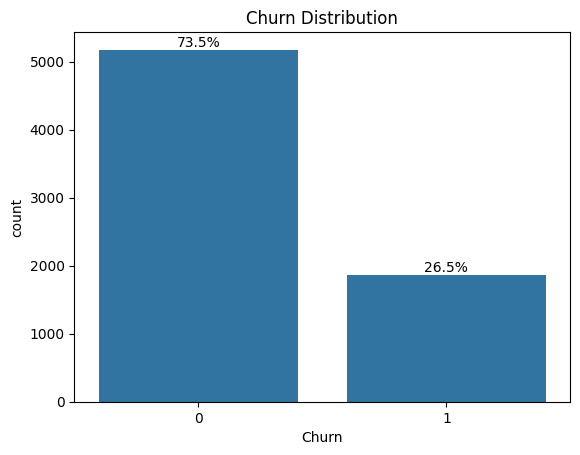

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")

# Add percentage labels
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.show()

## Churn Distribution Insight

Approximately 26–27% of customers churn, indicating a moderately imbalanced dataset.

This suggests that predicting churn is critical, as a significant portion of customers are leaving.

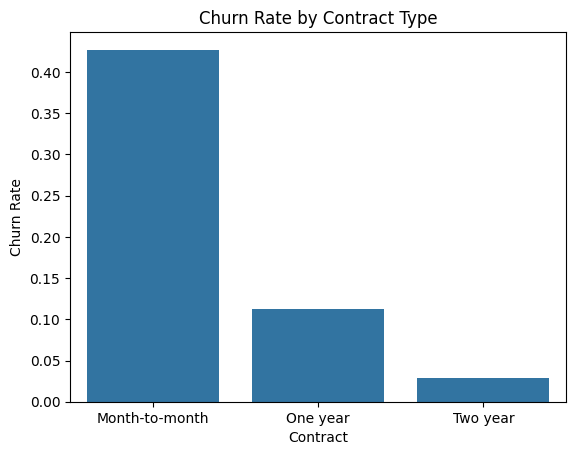

In [4]:
contract_churn = df.groupby('Contract')['Churn'].mean().reset_index()

sns.barplot(x='Contract', y='Churn', data=contract_churn)
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.show()

## Contract Type Insight

Customers with month-to-month contracts have the highest churn rate (~42%), 
compared to one-year (~11%) and two-year (~3%) contracts.

This indicates that long-term contracts significantly improve customer retention.

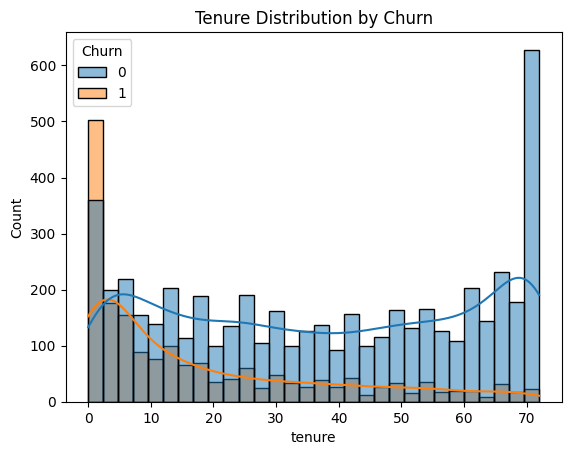

In [5]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title("Tenure Distribution by Churn")
plt.show()

## Tenure Insight

Customers with lower tenure are more likely to churn.

This suggests that the initial period after joining is critical for retention.

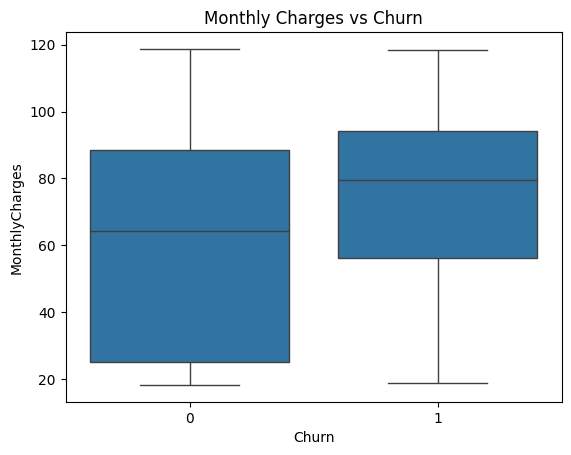

In [6]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

## Monthly Charges Insight

Customers who churn tend to have higher monthly charges.

High pricing without perceived value may lead to increased churn.

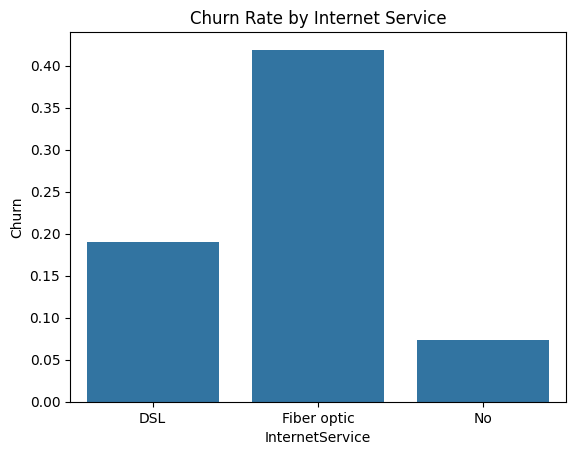

In [7]:
internet_churn = df.groupby('InternetService')['Churn'].mean().reset_index()

sns.barplot(x='InternetService', y='Churn', data=internet_churn)
plt.title("Churn Rate by Internet Service")
plt.show()

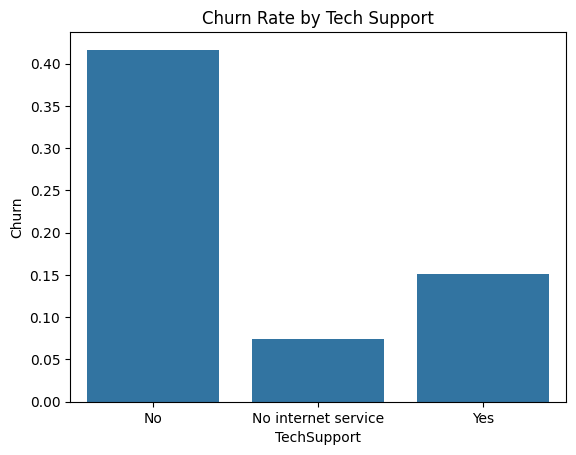

In [8]:
tech_churn = df.groupby('TechSupport')['Churn'].mean().reset_index()

sns.barplot(x='TechSupport', y='Churn', data=tech_churn)
plt.title("Churn Rate by Tech Support")
plt.show()

## Service Insight

Customers without Tech Support and Online Security have significantly higher churn rates.

Providing additional services can improve customer retention.

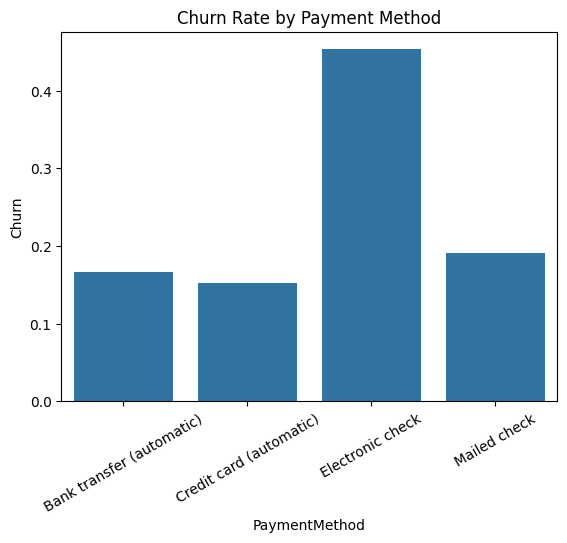

In [9]:
payment_churn = df.groupby('PaymentMethod')['Churn'].mean().reset_index()

sns.barplot(x='PaymentMethod', y='Churn', data=payment_churn)
plt.xticks(rotation=30)
plt.title("Churn Rate by Payment Method")
plt.show()

## Payment Method Insight

Customers using electronic check have the highest churn rate.

This may indicate lower engagement or commitment.

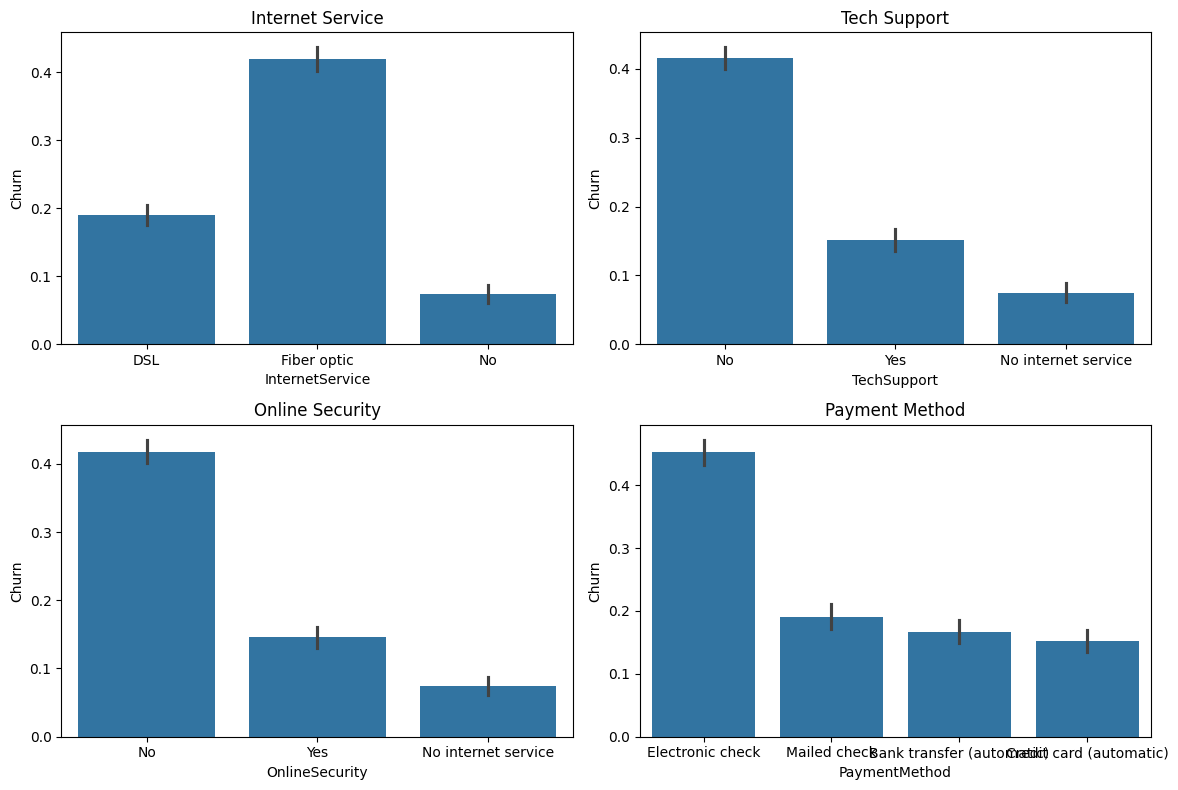

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.barplot(x='InternetService', y='Churn', data=df, ax=axes[0,0])
axes[0,0].set_title("Internet Service")

sns.barplot(x='TechSupport', y='Churn', data=df, ax=axes[0,1])
axes[0,1].set_title("Tech Support")

sns.barplot(x='OnlineSecurity', y='Churn', data=df, ax=axes[1,0])
axes[1,0].set_title("Online Security")

sns.barplot(x='PaymentMethod', y='Churn', data=df, ax=axes[1,1])
axes[1,1].set_title("Payment Method")

plt.tight_layout()
plt.show()

## Key Business Insights

1. Month-to-month contract customers have the highest churn (~42%)
2. Customers with low tenure churn more frequently
3. High monthly charges correlate with higher churn
4. Lack of services like Tech Support increases churn
5. Electronic check users show highest churn behavior

In [17]:
df_encoded = pd.get_dummies(df, drop_first=True)

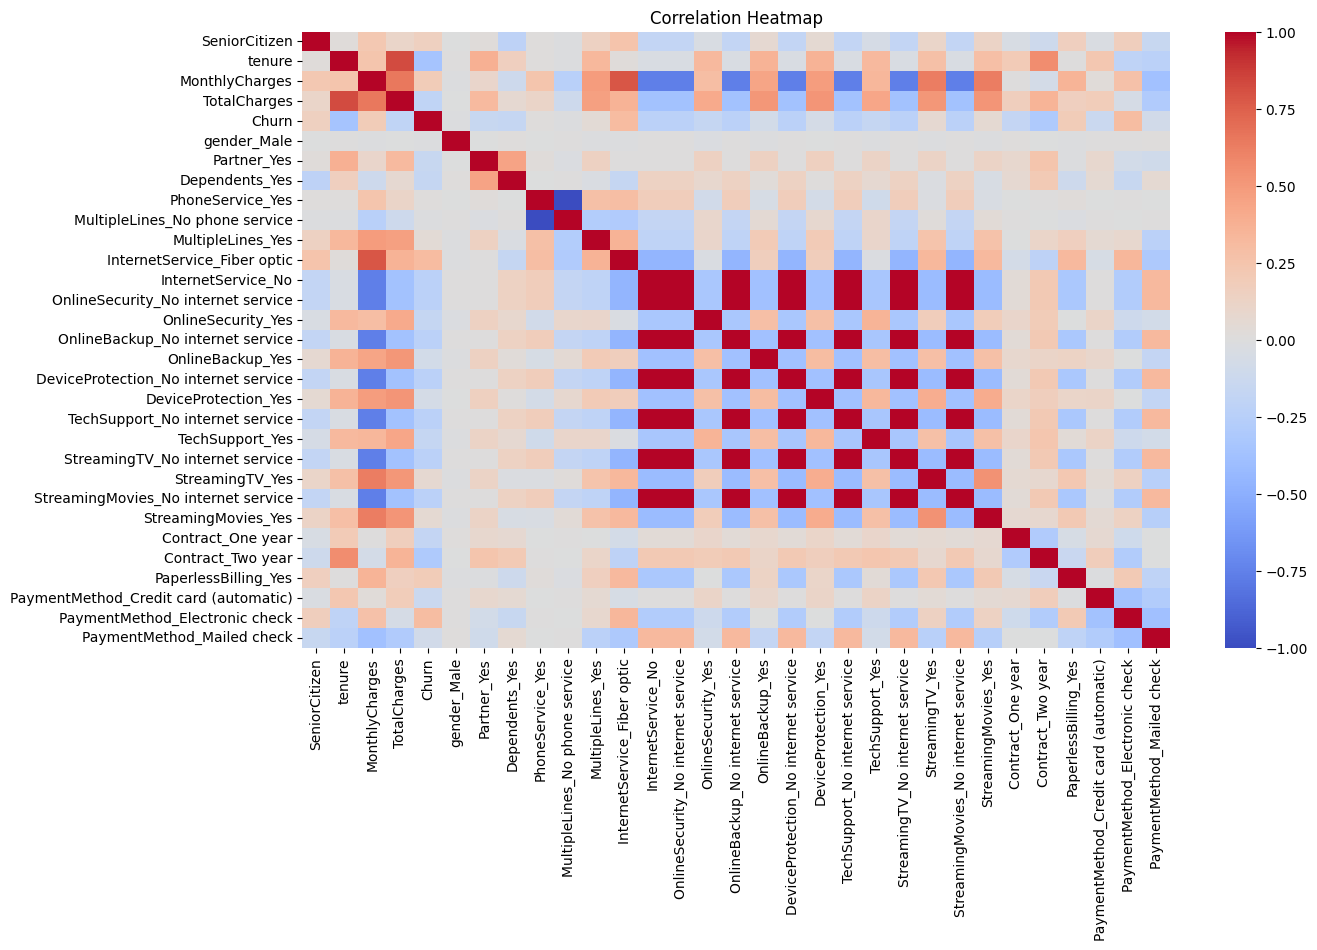

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [19]:
corr = df_encoded.corr()['Churn'].sort_values(ascending=False)
corr

Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling_Yes                     0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService_Yes                         0.011942
gender_Male                             -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner_Yes                             -0.150448
Dependents_Yes                          -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226


## Correlation Insights

Tenure is the most important feature negatively correlated with churn (-0.35), indicating that long-term customers are much less likely to leave.

Customers using fiber optic internet and electronic check payment methods show higher churn rates (~0.30 correlation).

Monthly charges and paperless billing also contribute positively to churn, suggesting that higher costs and certain billing behaviors influence customer decisions.

Long-term contracts (especially two-year contracts) significantly reduce churn.

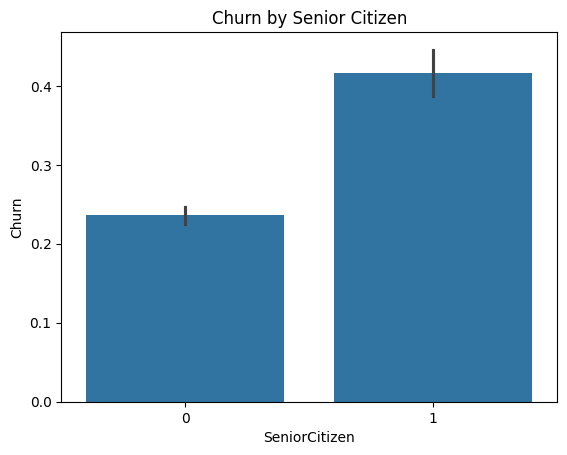

In [20]:
sns.barplot(x='SeniorCitizen', y='Churn', data=df)
plt.title("Churn by Senior Citizen")
plt.show()

## Senior Citizen Insight

Senior citizens have a higher churn rate compared to non-senior customers.

This may indicate the need for better support or tailored services.

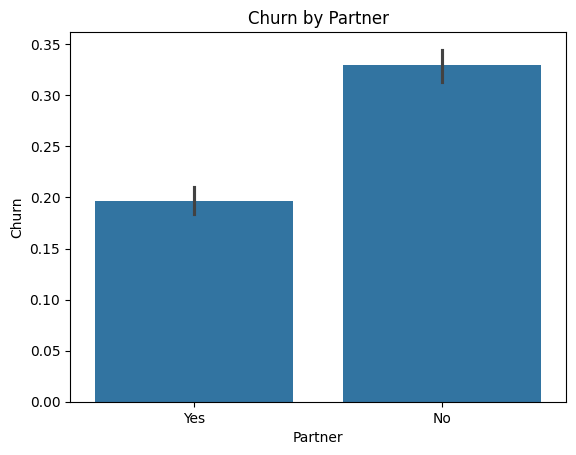

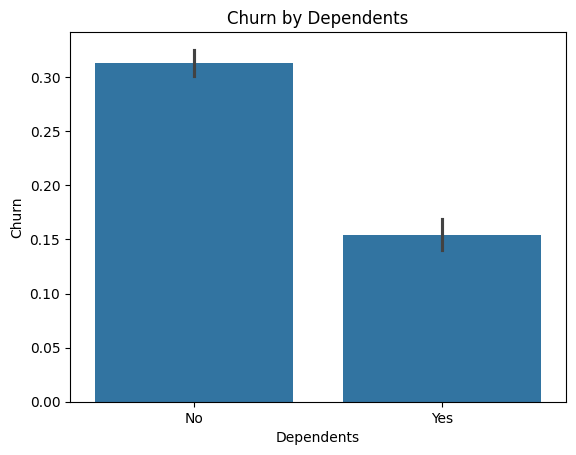

In [21]:
sns.barplot(x='Partner', y='Churn', data=df)
plt.title("Churn by Partner")
plt.show()

sns.barplot(x='Dependents', y='Churn', data=df)
plt.title("Churn by Dependents")
plt.show()

## Family Status Insight

Customers with partners and dependents tend to have lower churn rates.

This suggests that family-based customers are more stable and loyal.

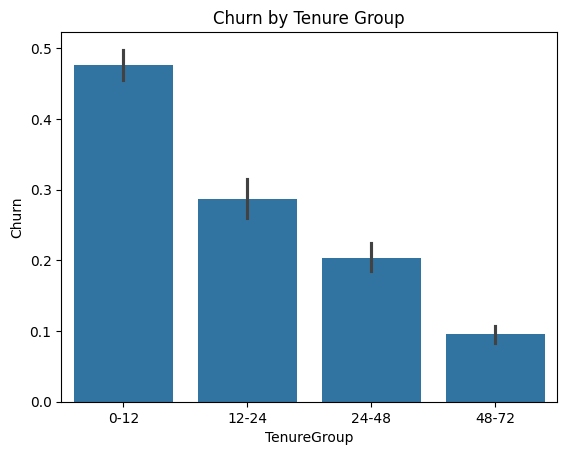

In [22]:
df['TenureGroup'] = pd.cut(df['tenure'], bins=[0,12,24,48,72],
                          labels=['0-12','12-24','24-48','48-72'])

sns.barplot(x='TenureGroup', y='Churn', data=df)
plt.title("Churn by Tenure Group")
plt.show()

## Tenure Group Insight

Customers with tenure less than 12 months have the highest churn rate.

Churn decreases significantly as tenure increases, highlighting the importance of early customer engagement.

## Final Business Insights

1. Month-to-month contracts have the highest churn rate.
2. Customers with low tenure (<12 months) are most likely to churn.
3. Higher monthly charges increase churn probability.
4. Customers without additional services like Tech Support are more likely to churn.
5. Family customers (with partner/dependents) are less likely to churn.